# Fine-Tuning

# Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_poisson_deviance, mean_gamma_deviance

# Downsteam GLM

# Using Fine-Tuned Model (after training)

In [2]:
train_df = np.load("embeddings/train_embeddings_belgium.npz")

test_df = np.load("embeddings/test_embeddings_belgium.npz")

In [3]:
meta_train = [train_df['y'], train_df['w']]

In [4]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


X_train = train_df['X']
meta_train = [train_df['y'], train_df['w']]

meta_train = pd.DataFrame({
    'ClaimNb': meta_train[0],
    'Exposure': meta_train[1]
})


X_test = test_df['X']
meta_test = [test_df['y'], test_df['w']]

meta_test = pd.DataFrame({
    'ClaimNb': meta_test[0],
    'Exposure': meta_test[1]
})

# Setup Scaler & PCA with Pandas Output
# ---------------------------------------------------------
scaler = StandardScaler().set_output(transform='pandas')
pca = PCA(n_components=100).set_output(transform='pandas')

# Pipeline Execution
# ---------------------------------------------------------
# TRAIN: Fit & Transform
# Scaler returns a DF with index preserved -> PCA returns a DF with index preserved
X_train_scaled = scaler.fit_transform(X_train)
X_train_pca = pca.fit_transform(X_train_scaled)

# TEST: Transform Only
X_test_scaled = scaler.transform(X_test)
X_test_pca = pca.transform(X_test_scaled)

# Fast Reconstruction
# ---------------------------------------------------------
# Because indices are preserved, pandas aligns rows automatically.

# Rename columns from 'pca0' to 'PC1', 'PC2'...
new_col_names = [f"PC{i+1}" for i in range(100)]
X_train_pca.columns = new_col_names
X_test_pca.columns = new_col_names

# Concatenate
final_train = pd.concat([X_train_pca, meta_train], axis=1)
final_test = pd.concat([X_test_pca, meta_test], axis=1)

print(f"Original Predictors: {len(X_train)}")
print(f"Reduced Predictors:  {X_train_pca.shape[1]}")
print(f"Final Train Shape:   {final_train.shape}")
print(final_train.head())

Original Predictors: 500000
Reduced Predictors:  100
Final Train Shape:   (500000, 102)
         PC1        PC2        PC3        PC4        PC5       PC6       PC7  \
0 -25.822016  -2.345669   1.314028  -4.875247   0.979143 -8.471014 -4.471782   
1 -23.787702 -14.958621 -15.040344  -1.045526  -5.290369 -1.639858 -1.802233   
2 -23.749536 -14.982235 -14.924001  -1.009323  -5.281511 -1.646348 -1.762755   
3 -24.997237   9.774358  -2.411185  10.830378  -3.733393  0.662547  0.390776   
4 -23.554819   4.208341  -1.703152 -11.136022 -11.876420 -0.100731  1.612300   

        PC8       PC9      PC10  ...      PC93      PC94      PC95      PC96  \
0 -5.032315  5.763799 -1.164336  ...  0.213987 -0.459626  0.887494  0.227427   
1 -2.003439 -5.080612 -1.940903  ... -0.449327  0.482123  0.079896 -0.190445   
2 -1.997145 -5.118227 -1.969908  ... -0.487236  0.502982  0.087435 -0.239356   
3  0.894292  0.746810  1.645148  ... -0.504607 -0.472843 -0.869389 -0.093067   
4 -1.135908 -5.412514 -0.869815

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Extract Variance Proportions
ex_var_ratio = pca.explained_variance_ratio_
cum_var_ratio = np.cumsum(ex_var_ratio)

# Create a Summary DataFrame
df_variance = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(len(ex_var_ratio))],
    'Individual_Variance': ex_var_ratio*100,
    'Cumulative_Variance': cum_var_ratio*100
})

df_variance

,Component,Individual_Variance,Cumulative_Variance
0,PC1,19.622848,19.622848
1,PC2,9.472868,29.095716
2,PC3,8.727347,37.823063
3,PC4,7.031428,44.854492
4,PC5,4.671656,49.526148
...,...,...,...
95,PC96,0.034224,98.368147
96,PC97,0.033296,98.401444
97,PC98,0.032123,98.433566
98,PC99,0.030084,98.463650


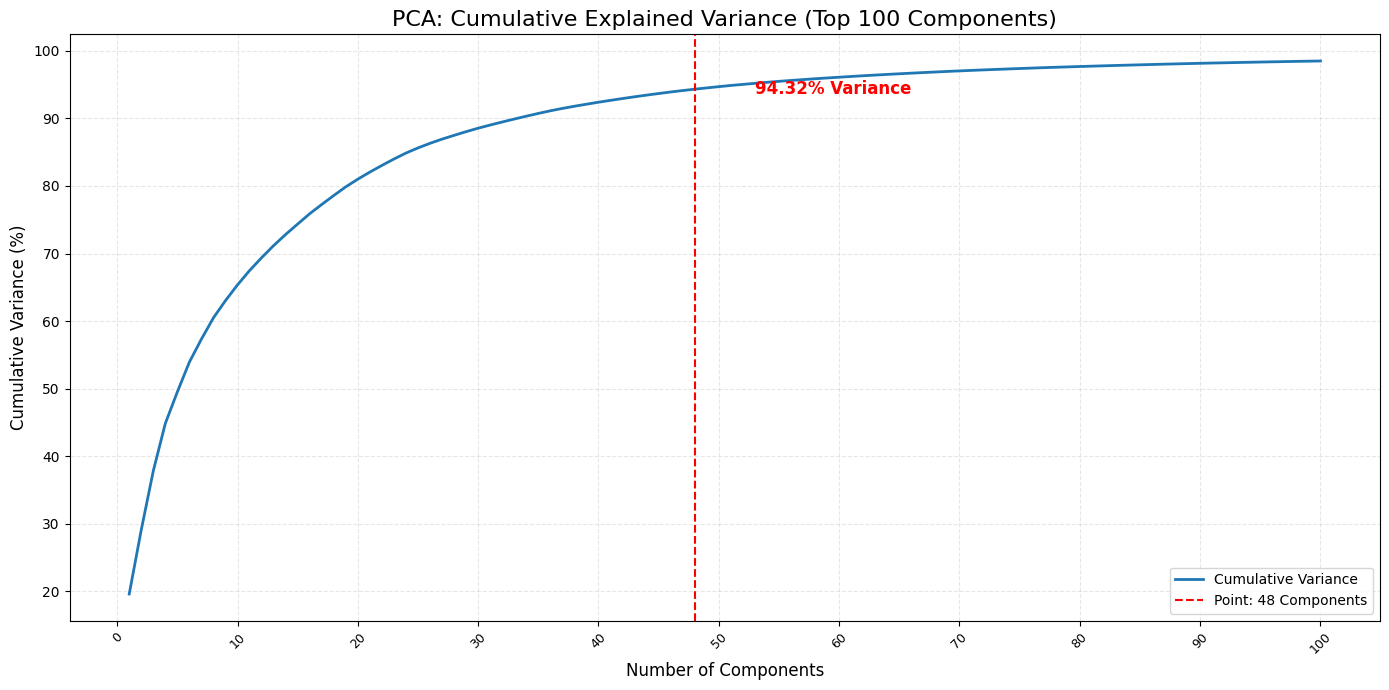

In [6]:
import matplotlib.pyplot as plt

# Filter the data to the first 500 components
df_subset = df_variance

# Extract the variance explained by exactly 48 components
# Since Python is 0-indexed, PC48 is at index 47
var_at_48 = df_subset.iloc[47]['Cumulative_Variance']

# Set up the figure
plt.figure(figsize=(14, 7))

# Plot the cumulative variance curve
plt.plot(range(1, len(df_subset) + 1), df_subset['Cumulative_Variance'], 
         color='tab:blue', linewidth=2, label='Cumulative Variance')

# Add a vertical line at 48 components
plt.axvline(x=48, color='red', linestyle='--', linewidth=1.5, label='Point: 48 Components')

# Add a text label showing the variance explained at n=48
# We offset the x position slightly (+5) so the text doesn't sit on the line
plt.text(48 + 5, var_at_48, f'{var_at_48:.2f}% Variance', 
         color='red', fontweight='bold', fontsize=12, verticalalignment='center')

# Set x-axis ticks to show every 10th component for clarity
plt.xticks(range(0, 101, 10), rotation=45, fontsize=9)

# Formatting labels and title
plt.title('PCA: Cumulative Explained Variance (Top 100 Components)', fontsize=16)
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Variance (%)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.legend(loc='lower right')

# Adjust layout and show
plt.tight_layout()
#plt.savefig('var_curve.png')
plt.show()

In [7]:
import pandas as pd

# Generate 1,024 column names (embedding_1, embedding_2, ..., embedding_1024)
# We use i+1 so the count starts at 1 instead of 0
col_names = [f"embedding_{i+1}" for i in range(X_train.shape[1])]

# Create the DataFrame
# usage of copy=False (optional) helps save memory by avoiding duplicating the large matrix
X_train = pd.DataFrame(X_train, columns=col_names, copy=False)

print(X_train.head())

   embedding_1  embedding_2  embedding_3  embedding_4  embedding_5  \
0    -0.005348    -0.016663    -0.012833     0.038361     0.071106   
1    -0.005875    -0.022919    -0.012924     0.041687     0.070435   
2    -0.005833    -0.022858    -0.012924     0.041718     0.070435   
3    -0.003267    -0.015259    -0.012688     0.043457     0.071899   
4    -0.004704    -0.018265    -0.013000     0.042969     0.074463   

   embedding_6  embedding_7  embedding_8  embedding_9  embedding_10  ...  \
0    -0.044220     0.006657     0.039642    -0.013985     -0.039856  ...   
1    -0.047180     0.004799     0.036285    -0.016190     -0.037109  ...   
2    -0.047150     0.004841     0.036377    -0.016205     -0.037109  ...   
3    -0.042969     0.007206     0.039276    -0.015526     -0.039917  ...   
4    -0.045258     0.005436     0.038574    -0.016510     -0.037933  ...   

   embedding_1015  embedding_1016  embedding_1017  embedding_1018  \
0        0.003527        0.016235       -0.012779    

/home/dkusmenko/.local/lib/python3.10/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


In [8]:
# Generate 1,024 column names (embedding_1, embedding_2, ..., embedding_1024)
# We use i+1 so the count starts at 1 instead of 0
col_names = [f"embedding_{i+1}" for i in range(X_test.shape[1])]

# Create the DataFrame
# usage of copy=False (optional) helps save memory by avoiding duplicating the large matrix
X_test = pd.DataFrame(X_test, columns=col_names, copy=False)


In [9]:
X_test

/home/dkusmenko/.local/lib/python3.10/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/home/dkusmenko/.local/lib/python3.10/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,embedding_1,embedding_2,embedding_3,embedding_4,embedding_5,embedding_6,embedding_7,embedding_8,embedding_9,embedding_10,...,embedding_1015,embedding_1016,embedding_1017,embedding_1018,embedding_1019,embedding_1020,embedding_1021,embedding_1022,embedding_1023,embedding_1024
0,-0.005367,-0.016617,-0.012833,0.038300,0.071045,-0.044220,0.006527,0.039612,-0.013870,-0.039703,...,0.003544,0.016190,-0.012718,-0.012405,0.020264,0.041626,-0.004711,0.015099,0.030182,-0.003664
1,-0.003347,-0.015213,-0.012680,0.043762,0.071899,-0.042999,0.007256,0.039459,-0.015526,-0.039795,...,0.002810,0.014503,-0.012802,-0.015259,0.019287,0.043030,-0.002916,0.017899,0.029388,-0.002468
2,-0.005074,-0.012550,-0.012741,0.044067,0.071533,-0.044678,0.004189,0.040070,-0.016220,-0.038483,...,0.000617,0.013855,-0.013306,-0.013474,0.020050,0.043854,-0.006069,0.017090,0.029984,-0.001802
3,-0.006676,-0.016907,-0.012833,0.040466,0.072815,-0.044067,0.005901,0.038788,-0.016312,-0.040161,...,0.003168,0.017151,-0.013367,-0.012222,0.021240,0.040558,-0.003462,0.015388,0.029434,-0.002846
4,-0.006817,-0.017578,-0.012917,0.040619,0.071716,-0.044983,0.005474,0.039246,-0.013313,-0.038910,...,0.002586,0.015671,-0.012833,-0.010864,0.021881,0.041565,-0.005531,0.016495,0.029816,-0.002087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,-0.005798,-0.013329,-0.012932,0.041565,0.068848,-0.044006,0.007408,0.038483,-0.019089,-0.037872,...,-0.001496,0.012901,-0.012695,-0.010574,0.020462,0.045013,-0.006264,0.014130,0.031433,-0.001550
99996,-0.009590,-0.019440,-0.012756,0.039642,0.067810,-0.045624,0.003078,0.041870,-0.013084,-0.037506,...,0.003323,0.013542,-0.011215,-0.012711,0.018951,0.046631,-0.001928,0.013527,0.025681,-0.004608
99997,-0.004181,-0.020172,-0.012794,0.040436,0.072388,-0.046783,0.005505,0.037872,-0.013680,-0.037567,...,0.002848,0.013123,-0.011963,-0.015388,0.021683,0.045166,-0.000220,0.014046,0.027679,-0.004612
99998,-0.009262,-0.017365,-0.012924,0.039734,0.070740,-0.045044,0.004902,0.039795,-0.014549,-0.038574,...,0.002821,0.016663,-0.011795,-0.010384,0.019226,0.043549,-0.005398,0.014900,0.028641,-0.001626


Processing Training Size: 200
Processing Training Size: 500
Processing Training Size: 1000
Processing Training Size: 2500
Processing Training Size: 5000
Processing Training Size: 10000
Processing Training Size: 15000
Processing Training Size: 20000
Processing Training Size: 30000
Processing Training Size: 50000
Processing Training Size: 80000


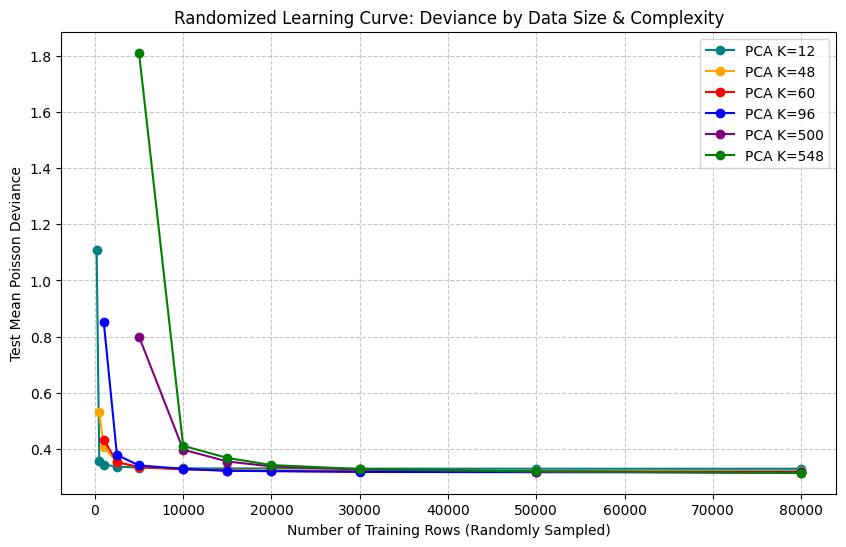

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_poisson_deviance
import statsmodels.api as sm
import gc

# -------------------------------------------------------
# Setup, Extraction & Random Shuffle
# -------------------------------------------------------
# Extracting arrays from the NpzFile 
X_raw_all = train_df['X']
y_raw_all = train_df['y']
w_raw_all = train_df['w']

# Create a random permutation of indices to shuffle X, y, and w together
np.random.seed(42)
indices = np.random.permutation(len(y_raw_all))

# Apply shuffled indices
X_train_shuffled = X_raw_all[indices]
y_train_shuffled = y_raw_all[indices]
offset_train_shuffled = w_raw_all[indices]

# Setup Test Data (Assuming test_df is also an NpzFile or similar)
X_test_raw = np.array(test_df['X'])
y_test = np.array(test_df['y'])
offset_test = np.array(test_df['w'])

# -------------------------------------------------------
# Configuration
# -------------------------------------------------------
# Use the same size logic, ensuring we don't exceed actual data size
max_available = len(y_train_shuffled)
train_sizes = [s for s in [200, 500, 1000, 2500, 5000, 10000, 15000, 20000, 30000, 50000, 80000] if s <= max_available]

start_thresholds = {
    12: 200, 48: 500, 60: 1000, 96: 1000, 500: 5000, 548: 5000
}

component_sets = [12, 48, 60, 96, 500, 548]
results_history = {k: [] for k in component_sets}

# -------------------------------------------------------
# Learning Curve Loop (Randomly Sampled)
# -------------------------------------------------------
for size in train_sizes:
    print(f"Processing Training Size: {size}")
    
    # --- Slice Data (already shuffled, so iloc-equivalent slicing is random) ---
    X_train_sub = X_train_shuffled[:size]
    y_train_sub = y_train_shuffled[:size]
    off_train_sub = offset_train_shuffled[:size]
    
    # --- Scaling ---
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_sub)
    X_test_scaled = scaler.transform(X_test_raw)

    # --- PCA (Dynamic Fitting per Subset) ---
    n_features = X_train_scaled.shape[1]
    max_k_possible = min(size, n_features, 548)
    
    pca = PCA(n_components=max_k_possible, random_state=42)
    X_train_pca_all = pca.fit_transform(X_train_scaled)
    X_test_pca_all = pca.transform(X_test_scaled)

    # Cleanup intermediate large objects
    del X_train_scaled, X_test_scaled, scaler, pca
    gc.collect()

    # --- Loop through component configurations ---
    for k in component_sets:
        # Check Rules
        if size < start_thresholds[k] or k > max_k_possible:
            results_history[k].append(np.nan)
            continue
            
        # Slice components
        X_train_k = X_train_pca_all[:, :k]
        X_test_k = X_test_pca_all[:, :k]
        
        try:
            glm = sm.GLM(
                endog=y_train_sub, 
                exog=sm.add_constant(X_train_k), 
                offset=np.log(off_train_sub), 
                family=sm.families.Poisson()
            )
            res = glm.fit(disp=0)
            
            # Predict and Score
            X_test_glm = sm.add_constant(X_test_k, has_constant='add')
            preds = res.predict(exog=X_test_glm, offset=np.log(offset_test))
            
            mpd = mean_poisson_deviance(y_test, preds)
            results_history[k].append(mpd)
            
        except Exception as e:
            print(f"  Failed for k={k} at size={size}: {e}")
            results_history[k].append(np.nan)

    del X_train_pca_all, X_test_pca_all
    gc.collect()

# -------------------------------------------------------
# Plotting
# -------------------------------------------------------
plt.figure(figsize=(10, 6))
colors = {12: 'teal', 48: 'orange', 60: 'red', 96: 'blue', 500: 'purple', 548: 'green'}

for k in component_sets:
    # Filter NaNs for plotting
    valid_mask = [not np.isnan(r) for r in results_history[k]]
    sizes_valid = [s for s, m in zip(train_sizes, valid_mask) if m]
    scores_valid = [r for r, m in zip(results_history[k], valid_mask) if m]
    
    plt.plot(sizes_valid, scores_valid, marker='o', linestyle='-', 
             color=colors.get(k, 'black'), label=f'PCA K={k}')

plt.title('Randomized Learning Curve: Deviance by Data Size & Complexity')
plt.xlabel('Number of Training Rows (Randomly Sampled)')
plt.ylabel('Test Mean Poisson Deviance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## Learning Curves

Size 500: 0.54030
Size 1077: 0.38681
Size 2320: 0.34931
Size 4999: 0.33606
Size 10772: 0.32656
Size 23207: 0.32266
Size 49999: 0.32128
Size 107721: 0.32050
Size 232079: 0.32027
Size 500000: 0.32019


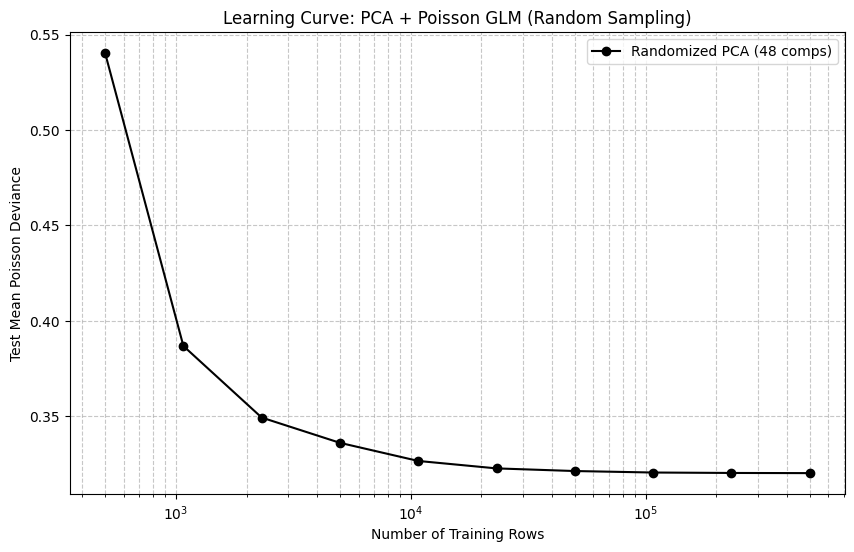

In [3]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.decomposition import PCA
from sklearn.metrics import mean_poisson_deviance
import matplotlib.pyplot as plt

# -------------------------------------------------------
# 1. Handle NpzFile and Shuffle
# -------------------------------------------------------
# Extracting arrays from the NpzFile object (per image_67e156.png)
# We use .copy() to ensure the arrays are in-memory and mutable
X_raw_all = train_df['X']
y_raw_all = train_df['y']
w_raw_all = train_df['w']

# Create a random permutation of indices to shuffle X, y, and w together
np.random.seed(42)
indices = np.random.permutation(len(y_raw_all))

X_train_full = X_raw_all[indices]
y_train_full = y_raw_all[indices]
offset_train_full = w_raw_all[indices]

# Setup Test Data (Assuming test_df is also an NpzFile or similar)
# We convert to numpy arrays immediately for consistency
X_test_raw = np.array(test_df['X'])
y_test = np.array(test_df['y'])
offset_test = np.array(test_df['w'])

# -------------------------------------------------------
# 2. Learning Curve Loop
# -------------------------------------------------------
max_rows = len(y_train_full)
# Ensure we don't exceed actual data size
train_sizesr = np.geomspace(500, min(500000, max_rows), num=10, dtype=int)
deviancesr_2 = []
n_components = 48 

for size in train_sizesr:
    # Slice from the SHUFFLED numpy arrays
    X_train_sub_raw = X_train_full[:size]
    y_train_sub = y_train_full[:size]
    off_train_sub = offset_train_full[:size]
    
    try:
        # Fit PCA on the current training subset only
        pca = PCA(n_components=n_components)
        X_train_pca = pca.fit_transform(X_train_sub_raw)
        
        # Transform the FIXED Test set using the PCA fitted on this subset
        X_test_pca = pca.transform(X_test_raw)
        
        # Add constants for Statsmodels
        X_train_glm = sm.add_constant(X_train_pca)
        X_test_glm = sm.add_constant(X_test_pca, has_constant='add')
        
        # Fit GLM
        glm = sm.GLM(
            endog=y_train_sub, 
            exog=X_train_glm, 
            offset=np.log(off_train_sub), 
            family=sm.families.Poisson()
        )
        results = glm.fit()
        
        # Predict on transformed Test Set
        preds = results.predict(exog=X_test_glm, offset=np.log(offset_test))
        
        # Score
        mpd = mean_poisson_deviance(y_test, preds)
        deviancesr_2.append(mpd)
        print(f"Size {size}: {mpd:.5f}")
        
    except Exception as e:
        print(f"Size {size} failed: {e}")
        deviancesr_2.append(None)

# -------------------------------------------------------
# 3. Plotting 
# -------------------------------------------------------
plt.figure(figsize=(10, 6))

# Filter out potential None values for the plot
valid_indices = [i for i, v in enumerate(deviancesr_2) if v is not None]
plt.plot(
    np.array(train_sizesr)[valid_indices], 
    np.array(deviancesr_2)[valid_indices], 
    marker='o', color='black', label=f'Randomized PCA ({n_components} comps)'
)

plt.xscale('log')
plt.title('Learning Curve: PCA + Poisson GLM (Random Sampling)')
plt.xlabel('Number of Training Rows')
plt.ylabel('Test Mean Poisson Deviance')
plt.grid(True, linestyle='--', alpha=0.7, which='both')
plt.legend()
plt.show()